# Unit 4 — Notebook 3: Comparing AWS, Azure, and GCP for ML Deployment

**What you will learn:**
1. The three tiers of cloud ML deployment (IaaS, CaaS, PaaS) and when to use each
2. The concrete differences between AWS SageMaker, GCP Vertex AI, and Azure ML
3. How to estimate monthly serving cost based on request volume
4. What vendor lock-in means and how containerization reduces it

**No cloud credentials needed** — this notebook runs entirely on your local Python environment.


---
## Section 1 — Three Tiers of Cloud ML Deployment

Cloud providers offer ML deployment at three levels of abstraction. The more abstraction, the less you manage — but also the less control you have.

### Tier 1: IaaS — Infrastructure as a Service
You rent a virtual machine (VM). You install Docker, your app, your dependencies. You manage everything above the hypervisor.

- **Examples:** AWS EC2, GCP Compute Engine, Azure VM
- **You manage:** OS updates, Docker, auto-scaling, health checks, load balancers
- **Good when:** You need full control, or unusual hardware (custom GPU configs)

### Tier 2: CaaS — Containers as a Service
You provide a Docker image. The cloud runs it in a managed container cluster (managed Kubernetes).

- **Examples:** AWS ECS / EKS, GCP GKE, Azure AKS
- **You manage:** Docker image, Kubernetes YAML
- **Good when:** You need K8s power without managing the control plane

### Tier 3: PaaS — Platform as a Service (Managed ML Endpoints)
You provide a model file and a scoring script. The platform handles everything else — containers, auto-scaling, A/B testing, model registry, monitoring.

- **Examples:** AWS SageMaker, GCP Vertex AI, Azure Machine Learning
- **You manage:** Model artifact, inference code
- **Good when:** You want to ship fast and are willing to pay the abstraction tax


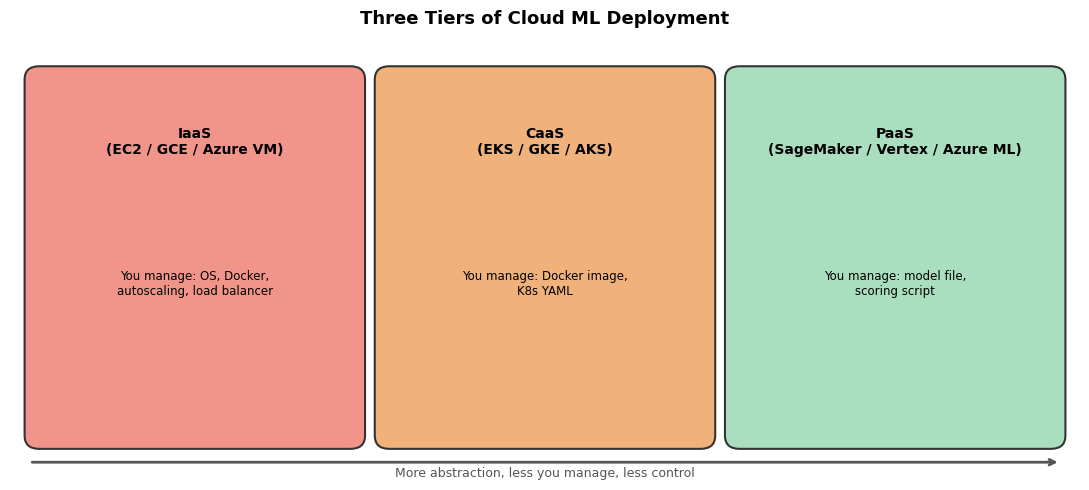

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_xlim(0, 11)
ax.set_ylim(0, 5)
ax.axis('off')

tiers = [
    (0.3, 'IaaS\n(EC2 / GCE / Azure VM)',
     'You manage: OS, Docker,\nautoscaling, load balancer',
     '#F1948A'),
    (3.9, 'CaaS\n(EKS / GKE / AKS)',
     'You manage: Docker image,\nK8s YAML',
     '#F0B27A'),
    (7.5, 'PaaS\n(SageMaker / Vertex / Azure ML)',
     'You manage: model file,\nscoring script',
     '#A9DFBF'),
]

for x, title, detail, color in tiers:
    rect = mpatches.FancyBboxPatch((x, 0.5), 3.2, 4.0,
                                    boxstyle='round,pad=0.15',
                                    facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 1.6, 3.8, title, ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(x + 1.6, 2.2, detail, ha='center', va='center', fontsize=8.5)

# Arrow from IaaS to PaaS: more abstraction →
ax.annotate('', xy=(10.8, 0.2), xytext=(0.2, 0.2),
            arrowprops=dict(arrowstyle='->', lw=2, color='#555'))
ax.text(5.5, 0.0, 'More abstraction, less you manage, less control',
        ha='center', va='bottom', fontsize=9, color='#555')

ax.set_title('Three Tiers of Cloud ML Deployment', fontsize=13, fontweight='bold', pad=8)
plt.tight_layout()
plt.show()


---
## Section 2 — Platform Comparison Table

Let's build a structured comparison of the three major PaaS ML platforms using pandas.


In [2]:
import pandas as pd

data = {
    "Feature": [
        "Auto-scaling",
        "Serving framework",
        "Model registry",
        "Built-in monitoring",
        "MLflow support",
        "Spot / preemptible instances",
        "Supported frameworks",
        "Pricing model",
        "Best for",
    ],
    "AWS SageMaker": [
        "Yes (target tracking)",
        "TorchServe, TF Serving, custom",
        "SageMaker Model Registry",
        "CloudWatch + Model Monitor",
        "Via MLflow tracking server",
        "Yes (Spot training)",
        "TF, PyTorch, sklearn, XGBoost, HuggingFace",
        "Per instance-hour + per GB data",
        "Teams already in AWS ecosystem",
    ],
    "GCP Vertex AI": [
        "Yes (request-based)",
        "TF Serving, custom container",
        "Vertex Model Registry",
        "Cloud Monitoring + Explainability",
        "Managed MLflow on Vertex",
        "Yes (preemptible VMs)",
        "TF, PyTorch, sklearn, XGBoost",
        "Per vCPU-hour + per GB",
        "TensorFlow workloads; BigQuery integration",
    ],
    "Azure ML": [
        "Yes (manual + auto rules)",
        "ONNX, TF, PyTorch, custom",
        "Azure ML Model Registry",
        "Application Insights + Data Drift",
        "Native MLflow integration",
        "Yes (low-priority VMs)",
        "TF, PyTorch, sklearn, ONNX",
        "Per compute-hour + storage",
        "Enterprise Microsoft/Azure stack",
    ],
}

df = pd.DataFrame(data)
df = df.set_index("Feature")

# Display with styling
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', 120)
print(df.to_string())


                                                           AWS SageMaker                               GCP Vertex AI                           Azure ML
Feature                                                                                                                                                
Auto-scaling                                       Yes (target tracking)                         Yes (request-based)          Yes (manual + auto rules)
Serving framework                         TorchServe, TF Serving, custom                TF Serving, custom container          ONNX, TF, PyTorch, custom
Model registry                                  SageMaker Model Registry                       Vertex Model Registry            Azure ML Model Registry
Built-in monitoring                           CloudWatch + Model Monitor           Cloud Monitoring + Explainability  Application Insights + Data Drift
MLflow support                                Via MLflow tracking server                

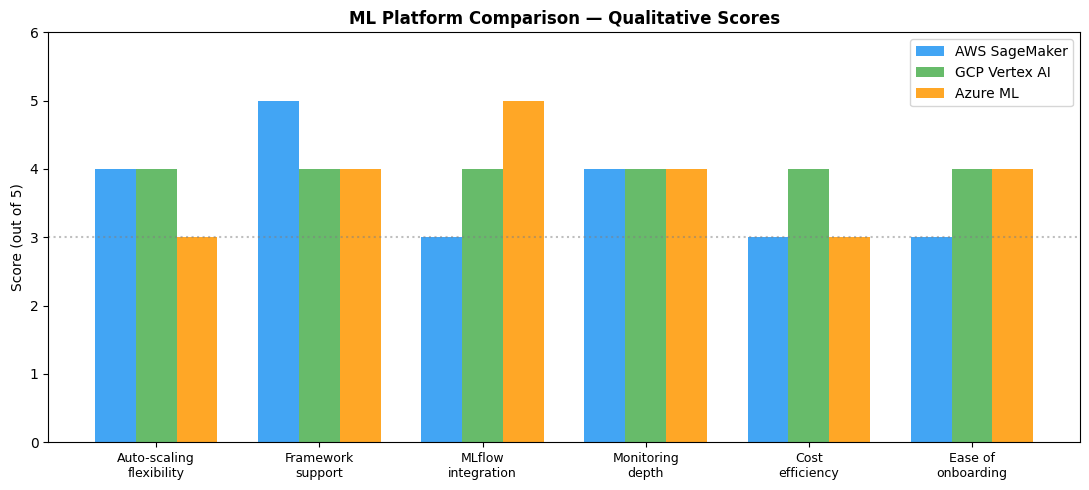

Note: scores are illustrative based on documentation and community feedback.
Evaluate against your specific workload before choosing.


In [3]:
# Visualise a qualitative score comparison across key dimensions
import matplotlib.pyplot as plt
import numpy as np

categories = [
    'Auto-scaling\nflexibility',
    'Framework\nsupport',
    'MLflow\nintegration',
    'Monitoring\ndepth',
    'Cost\nefficiency',
    'Ease of\nonboarding',
]

# Scores out of 5 (illustrative, based on documentation depth and community reports)
scores = {
    'AWS SageMaker': [4, 5, 3, 4, 3, 3],
    'GCP Vertex AI': [4, 4, 4, 4, 4, 4],
    'Azure ML':      [3, 4, 5, 4, 3, 4],
}

x = np.arange(len(categories))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800']
for i, (platform, vals) in enumerate(scores.items()):
    ax.bar(x + i * width, vals, width, label=platform, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(categories, fontsize=9)
ax.set_ylim(0, 6)
ax.set_ylabel('Score (out of 5)')
ax.set_title('ML Platform Comparison — Qualitative Scores', fontsize=12, fontweight='bold')
ax.legend()
ax.axhline(3, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print("Note: scores are illustrative based on documentation and community feedback.")
print("Evaluate against your specific workload before choosing.")


---
## Section 3 — Decision Tree: Choosing a Platform

Use this flowchart to guide your choice. Start at the top.

```
Is your team already invested in one cloud provider's services?
  ├─ Yes, AWS  → Start with SageMaker. Use Spot instances for training.
  ├─ Yes, GCP  → Start with Vertex AI. Best TensorFlow support + BigQuery integration.
  └─ Yes, Azure / Microsoft stack → Azure ML. Native MLflow, Active Directory integration.

Do you need maximum control over the serving infrastructure?
  └─ Yes → Self-managed Kubernetes (EKS / GKE / AKS).
           You write K8s YAML (like Notebook 02) and own every config.

Do you need to deploy in <1 day with no DevOps team?
  └─ Yes → Any managed endpoint (SageMaker, Vertex, Azure ML).
           They handle the container, load balancer, and auto-scaling for you.

Are you multi-cloud or open-source first?
  └─ Yes → Docker + Kubernetes on any cloud.
           Your images are portable. Avoid platform-specific SDKs in inference code.
```


---
## Section 4 — Cost Estimation

Cloud serving costs depend on: how many requests per day, how long each takes (which determines how many instances you need), and the instance type cost. The function below estimates monthly cost for a given workload.


In [4]:
def estimate_monthly_cost(
    requests_per_day: int,
    avg_latency_ms: float,
    instance_cost_per_hour: float,
    requests_per_instance_per_second: float = 50.0,
    redundancy_factor: float = 1.5,
    label: str = ""
) -> dict:
    """
    Estimate monthly serving cost.

    Parameters
    ----------
    requests_per_day          : total daily requests
    avg_latency_ms            : average inference latency in milliseconds
    instance_cost_per_hour    : cost of one inference instance (USD/hr)
    requests_per_instance_per_second : throughput per instance
    redundancy_factor         : multiply instance count for HA (1.5 = 50% extra)
    label                     : name for this scenario
    """
    # Peak requests per second (assuming traffic concentrated in 8 hours)
    peak_rps = requests_per_day / (8 * 3600)

    # Minimum instances needed to handle peak
    instances_needed = max(1, peak_rps / requests_per_instance_per_second)

    # Apply redundancy for high availability
    instances_with_ha = instances_needed * redundancy_factor

    # Monthly cost (730 hours/month)
    monthly_cost = instances_with_ha * instance_cost_per_hour * 730

    return {
        "scenario": label,
        "requests_per_day": requests_per_day,
        "peak_rps": round(peak_rps, 2),
        "instances_needed": round(instances_with_ha, 1),
        "monthly_cost_usd": round(monthly_cost, 2),
    }


# Light workload: a small internal tool or demo
light = estimate_monthly_cost(
    requests_per_day=10_000,
    avg_latency_ms=20,
    instance_cost_per_hour=0.12,   # e.g., ml.t2.medium on SageMaker
    label="Light (10K req/day)"
)

# Heavy workload: production consumer-facing API
heavy = estimate_monthly_cost(
    requests_per_day=1_000_000,
    avg_latency_ms=20,
    instance_cost_per_hour=0.12,
    label="Heavy (1M req/day)"
)

# GPU workload: large model inference
gpu = estimate_monthly_cost(
    requests_per_day=100_000,
    avg_latency_ms=80,
    instance_cost_per_hour=2.10,   # e.g., ml.g4dn.xlarge
    requests_per_instance_per_second=10,
    label="GPU (100K req/day, large model)"
)

import pandas as pd
results = pd.DataFrame([light, heavy, gpu])
print(results.to_string(index=False))
print()
print("These are rough estimates. Actual costs depend on data transfer, storage,")
print("monitoring, and whether you use reserved vs on-demand pricing.")


                       scenario  requests_per_day  peak_rps  instances_needed  monthly_cost_usd
            Light (10K req/day)             10000      0.35               1.5             131.4
             Heavy (1M req/day)           1000000     34.72               1.5             131.4
GPU (100K req/day, large model)            100000      3.47               1.5            2299.5

These are rough estimates. Actual costs depend on data transfer, storage,
monitoring, and whether you use reserved vs on-demand pricing.


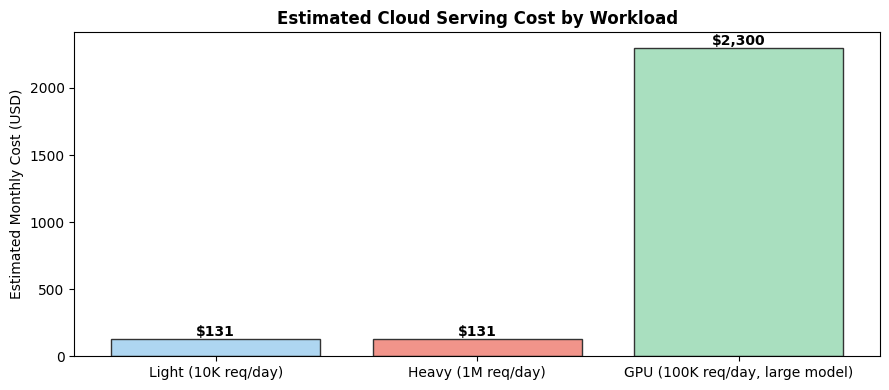

In [5]:
import matplotlib.pyplot as plt

scenarios = [light, heavy, gpu]
labels = [s["scenario"] for s in scenarios]
costs = [s["monthly_cost_usd"] for s in scenarios]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, costs, color=['#AED6F1', '#F1948A', '#A9DFBF'], edgecolor='#333')
ax.set_ylabel('Estimated Monthly Cost (USD)')
ax.set_title('Estimated Cloud Serving Cost by Workload', fontweight='bold')

for bar, cost in zip(bars, costs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'${cost:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


---
## Section 5 — Vendor Lock-In and Portability

**Vendor lock-in** means your application becomes so dependent on one cloud provider's specific APIs and services that switching is prohibitively expensive.

For ML deployment, lock-in risk increases when you:
- Use provider-specific inference containers (e.g., SageMaker's built-in TF container with SageMaker-only configuration)
- Store model artifacts in proprietary format tied to the provider's registry
- Call provider SDKs (`boto3.client('sagemaker')`) directly in your inference code

**How containerization reduces lock-in:**

If your model runs in a standard Docker container with a plain HTTP API (like Notebook 01), you can move it to any cloud or on-premise server with minimal changes. The container is the portability layer.

### Portability Spectrum


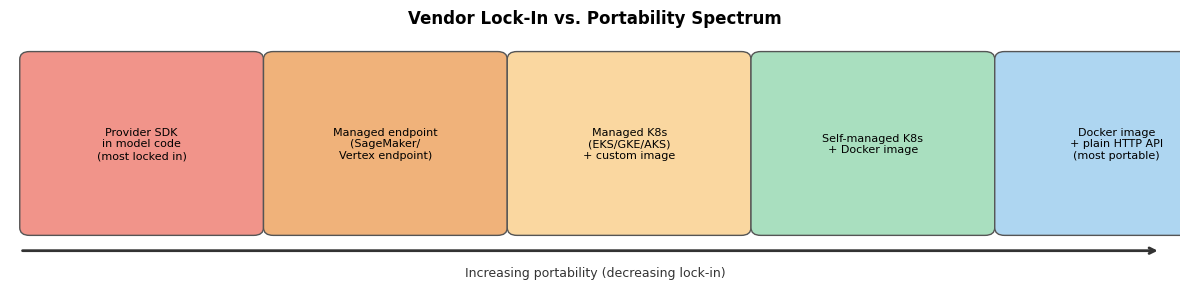

Key rule: keep provider-specific code outside your inference logic.
Inference code should only read a model file and return predictions.


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 3))
ax.set_xlim(0, 12)
ax.set_ylim(0, 3)
ax.axis('off')

items = [
    (0.2,  '#F1948A', 'Provider SDK\nin model code\n(most locked in)'),
    (2.7,  '#F0B27A', 'Managed endpoint\n(SageMaker/\nVertex endpoint)'),
    (5.2,  '#FAD7A0', 'Managed K8s\n(EKS/GKE/AKS)\n+ custom image'),
    (7.7,  '#A9DFBF', 'Self-managed K8s\n+ Docker image'),
    (10.2, '#AED6F1', 'Docker image\n+ plain HTTP API\n(most portable)'),
]

for x, color, label in items:
    rect = mpatches.FancyBboxPatch((x, 0.4), 2.3, 2.2,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='#555', linewidth=1)
    ax.add_patch(rect)
    ax.text(x + 1.15, 1.5, label, ha='center', va='center', fontsize=8)

ax.annotate('', xy=(11.8, 0.1), xytext=(0.1, 0.1),
            arrowprops=dict(arrowstyle='->', lw=2, color='#333'))
ax.text(6.0, -0.1, 'Increasing portability (decreasing lock-in)',
        ha='center', va='top', fontsize=9, color='#333')

ax.set_title('Vendor Lock-In vs. Portability Spectrum', fontsize=12, fontweight='bold', pad=4)
plt.tight_layout()
plt.show()

print("Key rule: keep provider-specific code outside your inference logic.")
print("Inference code should only read a model file and return predictions.")


---
## Summary

Choosing a cloud platform for ML deployment comes down to three variables:

1. **Your existing infrastructure** — if your team is already on AWS, SageMaker is the path of least resistance. Cross-cloud migrations are expensive.
2. **Your control requirements** — PaaS is fastest to deploy; self-managed K8s gives the most tuning control.
3. **Your cost model** — per-prediction pricing (SageMaker serverless, Vertex online prediction) is great for variable traffic; per-hour is better for steady high-volume workloads.

Containerizing your model with Docker (Notebook 01) keeps your options open regardless of which platform you start with.

**Next:** Notebook 04 covers CI/CD — how to automate the entire pipeline from code commit to deployed model.


---
## Self-Check Questions

1. **If you need to deploy a PyTorch model with minimal infrastructure management, which service would you start with on AWS?**
   *(Hint: which tier and which specific service name?)*

2. **What is vendor lock-in and how does containerization reduce it?**
   *(Hint: think about what changes when you move a Docker container vs. a SageMaker-specific endpoint to a different cloud.)*

3. **Why is pricing per-prediction different from pricing per-hour, and which is better for bursty traffic?**
   *(Hint: think about what you pay during periods of zero traffic.)*
